In [21]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor

# --- CONFIGURACIÓN ---
CATEGORY_NAME = "Audio___Media_Systems" # El nombre que usaste en el archivo (sin espacios raros)
ORIGINAL_CSV_PATH = "../amazon_specs_definitivo.csv" # Tu dataset gigante

# 1. Cargar el Dataset Original (Solo para recuperar títulos y marcas)
print("Cargando dataset maestro...")
df_original = pd.read_csv(ORIGINAL_CSV_PATH)

# 2. Cargar los datos de validación que guardamos en el script
print("Cargando datos de validación...")
val_df = pd.read_csv(f"val_data_{CATEGORY_NAME}.csv", index_col=0) # index_col=0 usa el índice original

# Separar X e y
y_val_log = val_df['target_log_real']
X_val = val_df.drop(columns=['target_log_real'])

# Nota: Al cargar de CSV, a veces Pandas pierde el tipo de dato. 
# Aseguramos que las columnas que eran categóricas se traten como strings/object
# (Esto asume que sabes cuáles son, o simplemente convertimos todas las object a string)
cat_cols = X_val.select_dtypes(include=['object']).columns
X_val[cat_cols] = X_val[cat_cols].fillna("Unknown").astype(str)

# 3. Cargar el Modelo
print("Cargando modelo...")
model = CatBoostRegressor()
model.load_model(f"model_catboost_{CATEGORY_NAME}.cbm")

# 4. Hacer Predicciones
print("Calculando predicciones...")
preds_log = model.predict(X_val)

# 5. Invertir Logaritmos (Log -> Euros)
# OJO: Si usaste np.log1p usa np.expm1. Si usaste np.log usa np.exp.
preds_euros = np.exp(preds_log) 
real_euros = np.exp(y_val_log)

# 6. Crear DataFrame de Análisis
analysis = pd.DataFrame({
    'Real_€': real_euros,
    'Pred_€': preds_euros,
    'Error_€': real_euros - preds_euros,
    'Error_Abs': np.abs(real_euros - preds_euros)
}, index=X_val.index)

# 7. CRUCE MÁGICO: Traer el título y foto del dataset original
# Usamos el índice para "pescar" la info del df_original
cols_to_bring = ['original_title', 'brand', 'subtype', 'market_tier']
# Filtramos solo las columnas que existan
existing_cols = [c for c in cols_to_bring if c in df_original.columns]

final_view = df_original.loc[analysis.index, existing_cols].join(analysis)

# 8. Mostrar el TOP 10 de Peores Errores
top_10_errors = final_view.sort_values('Error_Abs', ascending=False).head(20)

print("\n=== TOP 10 PEORES PREDICCIONES ===")
display(top_10_errors[['original_title', 'Real_€', 'Pred_€', 'Error_€', 'subtype']])

# Opcional: Ver métricas globales
rmse = np.sqrt(((analysis['Real_€'] - analysis['Pred_€']) ** 2).mean())
print(f"\nRMSE Global en Notebook: {rmse:.2f}€")

Cargando dataset maestro...
Cargando datos de validación...
Cargando modelo...
Calculando predicciones...

=== TOP 10 PEORES PREDICCIONES ===


,original_title,Real_€,Pred_€,Error_€,subtype
1274,Sonos Sub 4 - Wireless Subwoofer - Black,730.99,178.540580,552.449420,subwoofer
2018,"Bose Smart Ultra Soundbar, Surround Sound Syst...",750.97,332.207881,418.762119,soundbar
3529,Polk Audio MagniFi Max AX SR 7.1.2 Channel Sou...,469.00,863.144634,-394.144634,soundbar
719,Shure SM7B Microphone - Vocal Dynamic Studio M...,440.00,107.897645,332.102355,microphone
2881,Audio-Technica AT-LP120XUSB-BK Direct-Drive Tu...,391.96,100.555415,291.404585,turntable
2447,Sony PS-LX310BT Belt Drive Turntable: Fully Au...,450.99,190.166404,260.823596,turntable
3647,Marshall Woburn III Bluetooth Wireless Speaker...,600.99,352.057061,248.932939,speaker
4194,Shure SE425 PRO Wired Earbuds - Professional S...,297.00,53.868664,243.131336,earbuds
284,Sonos Move 2 - Black - Wireless Portable Bluet...,400.98,160.458491,240.521509,speaker
1728,Klipsch Flexus CORE 200 3.1.2 Channel Powered ...,370.12,597.140440,-227.020440,soundbar



RMSE Global en Notebook: 103.82€


In [23]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor

# --- CONFIGURACIÓN ---
CATEGORY_NAME = "Audio___Media_Systems" # El nombre que usaste en el archivo (sin espacios raros)
ORIGINAL_CSV_PATH = "../amazon_specs_definitivo.csv" # Tu dataset gigante

# 1. Cargar el Dataset Original (Solo para recuperar títulos y marcas)
print("Cargando dataset maestro...")
df_original = pd.read_csv(ORIGINAL_CSV_PATH)

# 2. Cargar los datos de validación que guardamos en el script
print("Cargando datos de validación...")
val_df = pd.read_csv(f"val_data_{CATEGORY_NAME}_v2.csv", index_col=0) # index_col=0 usa el índice original

# Separar X e y
y_val_log = val_df['target_log_real']
X_val = val_df.drop(columns=['target_log_real'])

# Nota: Al cargar de CSV, a veces Pandas pierde el tipo de dato. 
# Aseguramos que las columnas que eran categóricas se traten como strings/object
# (Esto asume que sabes cuáles son, o simplemente convertimos todas las object a string)
cat_cols = X_val.select_dtypes(include=['object']).columns
X_val[cat_cols] = X_val[cat_cols].fillna("Unknown").astype(str)

# 3. Cargar el Modelo
print("Cargando modelo...")
model = CatBoostRegressor()
model.load_model(f"model_catboost_{CATEGORY_NAME}_v2.cbm")

# 4. Hacer Predicciones
print("Calculando predicciones...")
preds_log = model.predict(X_val)

# 5. Invertir Logaritmos (Log -> Euros)
# OJO: Si usaste np.log1p usa np.expm1. Si usaste np.log usa np.exp.
preds_euros = np.exp(preds_log) 
real_euros = np.exp(y_val_log)

# 6. Crear DataFrame de Análisis
analysis = pd.DataFrame({
    'Real_€': real_euros,
    'Pred_€': preds_euros,
    'Error_€': real_euros - preds_euros,
    'Error_Abs': np.abs(real_euros - preds_euros)
}, index=X_val.index)

# 7. CRUCE MÁGICO: Traer el título y foto del dataset original
# Usamos el índice para "pescar" la info del df_original
cols_to_bring = ['original_title', 'brand', 'subtype', 'market_tier']
# Filtramos solo las columnas que existan
existing_cols = [c for c in cols_to_bring if c in df_original.columns]

final_view = df_original.loc[analysis.index, existing_cols].join(analysis)

# 8. Mostrar el TOP 10 de Peores Errores
top_10_errors = final_view.sort_values('Error_Abs', ascending=False).head(20)

print("\n=== TOP 10 PEORES PREDICCIONES ===")
display(top_10_errors[['original_title', 'Real_€', 'Pred_€', 'Error_€', 'subtype']])

# Opcional: Ver métricas globales
rmse = np.sqrt(((analysis['Real_€'] - analysis['Pred_€']) ** 2).mean())
print(f"\nRMSE Global en Notebook: {rmse:.2f}€")

Cargando dataset maestro...
Cargando datos de validación...
Cargando modelo...
Calculando predicciones...

=== TOP 10 PEORES PREDICCIONES ===


,original_title,Real_€,Pred_€,Error_€,subtype
1274,Sonos Sub 4 - Wireless Subwoofer - Black,730.99,241.031514,489.958486,subwoofer
2018,"Bose Smart Ultra Soundbar, Surround Sound Syst...",750.97,352.115739,398.854261,soundbar
719,Shure SM7B Microphone - Vocal Dynamic Studio M...,440.00,118.855518,321.144482,microphone
2881,Audio-Technica AT-LP120XUSB-BK Direct-Drive Tu...,391.96,109.901473,282.058527,turntable
3647,Marshall Woburn III Bluetooth Wireless Speaker...,600.99,320.199104,280.790896,speaker
2447,Sony PS-LX310BT Belt Drive Turntable: Fully Au...,450.99,172.967876,278.022124,turntable
5526,"Sony BRAVIA Theater Bar 6, 3.1.2ch Sound bar w...",650.99,405.398656,245.591344,soundbar
3529,Polk Audio MagniFi Max AX SR 7.1.2 Channel Sou...,469.00,713.967002,-244.967002,soundbar
4194,Shure SE425 PRO Wired Earbuds - Professional S...,297.00,56.784281,240.215719,earbuds
3468,Razer Kraken V4 Pro Wireless Gaming Headset: O...,400.99,166.975581,234.014419,headphones



RMSE Global en Notebook: 99.18€


In [25]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor

# --- CONFIGURACIÓN ---
CATEGORY_NAME = "Audio___Media_Systems" # El nombre que usaste en el archivo (sin espacios raros)
ORIGINAL_CSV_PATH = "../amazon_specs_definitivo.csv" # Tu dataset gigante

# 1. Cargar el Dataset Original (Solo para recuperar títulos y marcas)
print("Cargando dataset maestro...")
df_original = pd.read_csv(ORIGINAL_CSV_PATH)

# 2. Cargar los datos de validación que guardamos en el script
print("Cargando datos de validación...")
val_df = pd.read_csv(f"val_data_{CATEGORY_NAME}_v2_MAE.csv", index_col=0) # index_col=0 usa el índice original

# Separar X e y
y_val_log = val_df['target_log_real']
X_val = val_df.drop(columns=['target_log_real'])

# Nota: Al cargar de CSV, a veces Pandas pierde el tipo de dato. 
# Aseguramos que las columnas que eran categóricas se traten como strings/object
# (Esto asume que sabes cuáles son, o simplemente convertimos todas las object a string)
cat_cols = X_val.select_dtypes(include=['object']).columns
X_val[cat_cols] = X_val[cat_cols].fillna("Unknown").astype(str)

# 3. Cargar el Modelo
print("Cargando modelo...")
model = CatBoostRegressor()
model.load_model(f"model_catboost_{CATEGORY_NAME}_v2_MAE.cbm")

# 4. Hacer Predicciones
print("Calculando predicciones...")
preds_log = model.predict(X_val)

# 5. Invertir Logaritmos (Log -> Euros)
# OJO: Si usaste np.log1p usa np.expm1. Si usaste np.log usa np.exp.
preds_euros = np.exp(preds_log) 
real_euros = np.exp(y_val_log)

# 6. Crear DataFrame de Análisis
analysis = pd.DataFrame({
    'Real_€': real_euros,
    'Pred_€': preds_euros,
    'Error_€': real_euros - preds_euros,
    'Error_Abs': np.abs(real_euros - preds_euros)
}, index=X_val.index)

# 7. CRUCE MÁGICO: Traer el título y foto del dataset original
# Usamos el índice para "pescar" la info del df_original
cols_to_bring = ['original_title', 'brand', 'subtype', 'market_tier']
# Filtramos solo las columnas que existan
existing_cols = [c for c in cols_to_bring if c in df_original.columns]

final_view = df_original.loc[analysis.index, existing_cols].join(analysis)

# 8. Mostrar el TOP 10 de Peores Errores
top_10_errors = final_view.sort_values('Error_Abs', ascending=False).head(20)

print("\n=== TOP 10 PEORES PREDICCIONES ===")
display(top_10_errors[['original_title', 'Real_€', 'Pred_€', 'Error_€', 'subtype']])

# Opcional: Ver métricas globales
rmse = np.sqrt(((analysis['Real_€'] - analysis['Pred_€']) ** 2).mean())
print(f"\nRMSE Global en Notebook: {rmse:.2f}€")

Cargando dataset maestro...
Cargando datos de validación...
Cargando modelo...
Calculando predicciones...

=== TOP 10 PEORES PREDICCIONES ===


,original_title,Real_€,Pred_€,Error_€,subtype
1274,Sonos Sub 4 - Wireless Subwoofer - Black,730.99,226.175938,504.814062,subwoofer
2018,"Bose Smart Ultra Soundbar, Surround Sound Syst...",750.97,314.877696,436.092304,soundbar
719,Shure SM7B Microphone - Vocal Dynamic Studio M...,440.00,134.700082,305.299918,microphone
3647,Marshall Woburn III Bluetooth Wireless Speaker...,600.99,299.150259,301.839741,speaker
3529,Polk Audio MagniFi Max AX SR 7.1.2 Channel Sou...,469.00,766.713967,-297.713967,soundbar
2881,Audio-Technica AT-LP120XUSB-BK Direct-Drive Tu...,391.96,96.884378,295.075622,turntable
2447,Sony PS-LX310BT Belt Drive Turntable: Fully Au...,450.99,186.102353,264.887647,turntable
4194,Shure SE425 PRO Wired Earbuds - Professional S...,297.00,47.663599,249.336401,earbuds
5526,"Sony BRAVIA Theater Bar 6, 3.1.2ch Sound bar w...",650.99,404.552010,246.437990,soundbar
284,Sonos Move 2 - Black - Wireless Portable Bluet...,400.98,172.199347,228.780653,speaker



RMSE Global en Notebook: 101.68€


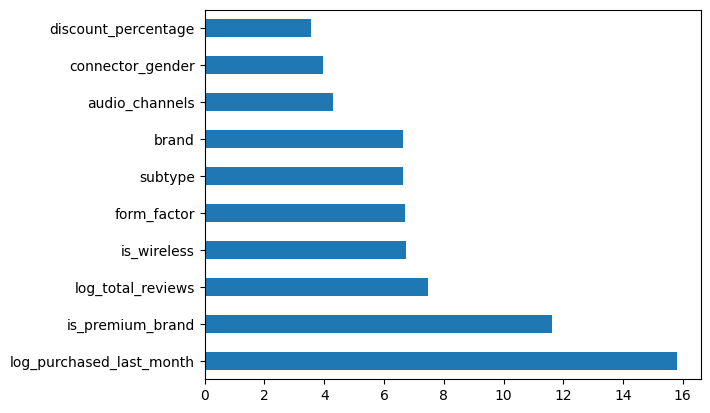

In [22]:
# Ver la importancia de las características
import matplotlib.pyplot as plt
feat_importances = pd.Series(model.get_feature_importance(), index=X_val.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

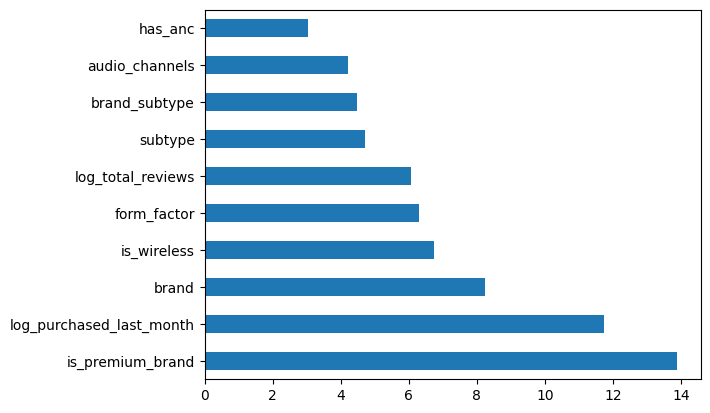

In [24]:
# Ver la importancia de las características
import matplotlib.pyplot as plt
feat_importances = pd.Series(model.get_feature_importance(), index=X_val.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [26]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
import warnings

# Suprimir warnings
warnings.filterwarnings('ignore')

# --- CONFIGURACIÓN ---
MODEL_PATH = "global_model_optimized.cbm"  
CSV_PATH = "../../../Datasets/evaluacion4.csv"

# Misma lista de características que el entrenamiento (CRÍTICO)
RAW_FEATURES = "category,subtype,market_tier,condition,is_premium_brand,tech_generation,brand,confidence,printer_tech,is_color,is_multifunction,paper_size_max,ppm,pack_count,is_xl,ups_capacity_value,ups_capacity_unit,is_rackmount,rack_u,power_capacity_value,power_capacity_unit,audio_channels,total_power_w,has_dolby_atmos,has_subwoofer,has_anc,form_factor,mic_type,audio_resolution,video_output_res,switch_type,dpi,has_screen,is_thunderbolt,max_resolution,read_speed_mbs,scan_engine,wifi_standard,speed_class,node_count,frequency_bands,has_poe,multi_gig_ports,power_source,smart_protocol,is_outdoor,screen_size_in,resolution_standard,panel_tech,refresh_rate_hz,is_smart,mount_type,adjustment_type,num_screens,max_weight_kg,is_heavy_duty,sensor_format,max_video_res,is_body_only,mount_system,megapixels,is_pro_line,focal_range,max_aperture_f,is_kit,component_series,vram_gb,has_x3d,ram_gb,storage_gb,tech_gen,power_wattage,efficiency_rating,chipset,is_aio,is_gaming,platform_family,is_digital_edition,nas_bays,model_name,cellular_type,has_stylus,case_size_mm,is_rugged,is_specialized,gps_activity,has_touchscreen,cable_length_m,interface_type,is_braided,material,brand_compatibility,is_active,is_original,connector_gender,is_wireless,port_count,storage_type,pd_wattage,case_keyboard,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,log_original_price,log_purchased_last_month,log_total_reviews,brand_subtype"

FEATURE_LIST = [f.strip() for f in RAW_FEATURES.split(',')]
TARGET = 'log_original_price'
FEATURES = [f for f in FEATURE_LIST if f != TARGET]

def analyze_validation_errors():
    print(f"📂 Cargando datos desde: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
    
    # --- 1. SEPARAR VALIDACIÓN (Igual que en el entrenamiento) ---
    print("✂️ Separando el 20% de Validación (random_state=42)...")
    _, val_df = train_test_split(df, test_size=0.2, random_state=42)
    
    print(f"   -> Analizando {len(val_df)} productos que el modelo NO ha visto.")
    
    # --- 2. PREPARAR DATOS ---
    X_val = val_df[FEATURES].copy()
    y_val_log = val_df[TARGET]
    
    # Tratamiento de categóricas (Rellenar con "Missing")
    # Esto es vital porque el modelo espera strings, no NaNs en las categóricas
    for col in X_val.columns:
        if X_val[col].dtype == 'object' or X_val[col].dtype.name == 'category' or X_val[col].dtype == 'bool':
            X_val[col] = X_val[col].fillna("Missing").astype(str)
            
    # --- 3. CARGAR MODELO Y PREDECIR ---
    print(f"🧠 Cargando modelo: {MODEL_PATH}")
    try:
        model = CatBoostRegressor()
        model.load_model(MODEL_PATH)
    except Exception as e:
        print(f"❌ Error cargando modelo: {e}")
        return

    print("🔮 Prediciendo...")
    preds_log = model.predict(X_val)
    
    # Invertir Log -> Euros
    preds_euro = np.exp(preds_log)
    y_real_euro = np.exp(y_val_log)
    
    # --- 4. ANÁLISIS DE RESIDUOS ---
    # Creamos un DF temporal para el análisis
    analysis = val_df[['category', 'brand', 'subtype']].copy()
    analysis['Precio_Real'] = y_real_euro
    analysis['Prediccion'] = preds_euro
    analysis['Error_Euros'] = analysis['Precio_Real'] - analysis['Prediccion']
    analysis['Error_Absoluto'] = analysis['Error_Euros'].abs()
    
    # --- 5. RESULTADOS POR CATEGORÍA ---
    print("\n📊 --- REPORTE DE ERRORES POR CATEGORÍA (VALIDACIÓN) ---")
    
    stats = analysis.groupby('category').agg(
        Productos=('Precio_Real', 'count'),
        MAE=('Error_Absoluto', 'mean'),
        RMSE=('Error_Euros', lambda x: np.sqrt(np.mean(x**2))),
        Precio_Medio=('Precio_Real', 'mean'),
        Error_Max=('Error_Absoluto', 'max')
    ).sort_values(by='MAE', ascending=False)
    
    # Formato bonito
    pd.options.display.float_format = '{:,.2f}'.format
    print(stats)
    
    # Guardar CSV
    stats.to_csv("analisis_validacion_por_categoria.csv")
    print("\n💾 Reporte detallado guardado en 'analisis_validacion_por_categoria.csv'")
    
    # --- CONSEJO FINAL ---
    worst_cat = stats.index[0]
    mae_worst = stats.iloc[0]['MAE']
    print(f"\n💡 CONCLUSIÓN: Tu mayor problema está en '{worst_cat}' (Error medio: {mae_worst:.2f}€).")
    if mae_worst > 100:
        print("   -> SUGERENCIA: El Modelo B debería enfocarse en esta categoría.")
    else:
        print("   -> SUGERENCIA: El error está bastante controlado. Un Modelo B Global suave funcionará bien.")

analyze_validation_errors()

📂 Cargando datos desde: ../../../Datasets/evaluacion4.csv
✂️ Separando el 20% de Validación (random_state=42)...
   -> Analizando 1289 productos que el modelo NO ha visto.
🧠 Cargando modelo: global_model_optimized.cbm
🔮 Prediciendo...

📊 --- REPORTE DE ERRORES POR CATEGORÍA (VALIDACIÓN) ---
                              Productos    MAE   RMSE  Precio_Medio  Error_Max
category                                                                      
Cameras, Photography & Video         96 391.92 712.17        820.28   2,615.49
Computers & Gaming                  101 173.45 304.79        689.17   1,585.14
Mobile Devices                       33 120.11 187.74        377.29     568.09
PC Components (Core)                100 101.42 194.62        282.02     871.34
Displays & Mounting                  86 100.87 164.71        322.54     665.76
Audio & Media Systems               171  65.80  97.60        157.69     363.83
Office, Printing & Power            372  49.47 111.69        129.55     926.